# Convolutional Neural Network for dog breed classification
In this project I will implement a CNN for multiclass classification on the Stanford Dogs public dataset.

# Imports

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import torchvision.transforms.v2
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

# Dataset loading
The images in the dataset are full resolution. I will resize and normalize them while loading to ease further use.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

load_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

dataset = ImageFolder(root='./Images', transform = load_transform)
print(f"Samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Samples: 20580
Number of classes: 120


# Data exploration

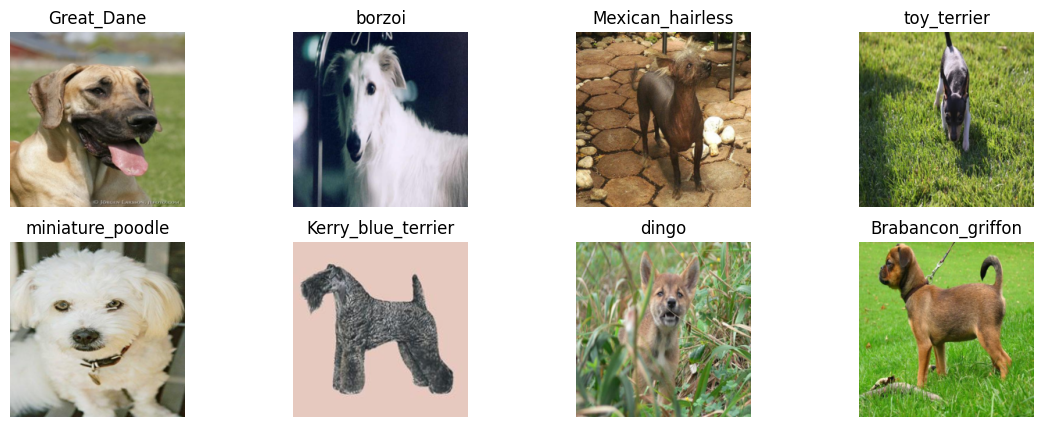

In [3]:
np.random.seed(42)

indices = np.random.choice(len(dataset), size=8, replace=False)

fig, axes = plt.subplots(2,4, figsize = (14,5))
axes = axes.flatten() # simpler indexing

for i, idx in enumerate(indices):
    img, label = dataset[idx]
    img = img.numpy().transpose(1,2,0) # (C, H, W) -> (H, W, C) matplotlib uses this format
    img = (img * IMAGENET_STD) + IMAGENET_MEAN # undo the normalization
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    hyphen_index = dataset.classes[label].find('-')
    axes[i].set_title(dataset.classes[label][hyphen_index+1:])
    axes[i].axis('off')
    
plt.show()

# Dataset splitting
I will use the built-in random_split from torch.utils.

In [4]:
from torch.utils.data import random_split

n_total = len(dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_split, val_split, test_split = random_split(dataset, [n_train, n_val, n_test])

print(f"Training samples: {len(train_split)}")
print(f"Validation samples: {len(val_split)}")
print(f"Test samples: {len(test_split)}")

Training samples: 14405
Validation samples: 3087
Test samples: 3088


# Iterators with data augmentation
As a means of averting overfitting, through data augmentation it is possible to create "new" samples to prevent the model from learning the dataset's specific features. Since the model trains only in the training phase, I will only augment the training dataset.

In [ ]:
class AugmentedDatasetIt(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x,y = self.dataset[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

train_transform = transforms.v2.Compose([
    transforms.v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.v2.RandomHorizontalFlip(),
    transforms.v2.GaussianNoise(mean=0.0, sigma=0.05),
    transforms.v2.RandomAffine(degrees=20., translate=(0.2,0.2), scale=(0.2,1.2))    
])

train_dataset = AugmentedDatasetIt(train_split, transform=train_transform)
val_dataset = AugmentedDatasetIt(val_split)
test_dataset = AugmentedDatasetIt(test_split)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, generator=g, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=8)

fig, axes = plt.subplots(1,2, figsize = (14,5))
axes = axes.flatten()

mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)

for im, lab in train_loader:

    im = (im * mean) + std
    im = np.clip(im, 0, 1)
    im_0 = im[0].numpy().transpose(1,2,0)
    im_1 = im[1].numpy().transpose(1,2,0)

    axes[0].imshow(im_0)
    axes[0].set_title(dataset.classes[lab[0]])
    axes[0].axis('off')

    axes[1].imshow(im_1)
    axes[1].set_title(dataset.classes[lab[1]])
    axes[1].axis('off')
    break

plt.show()

# Model definition
Let's start with the simplest CNN architecture. A few blocks of 2D convolutional and pooling layers aternatingly with a fully connected MLP-like block at the end. 

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=(3,3), padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2))
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=(3,3), padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2))
        )
        self.fully_connected = nn.Sequential(
            nn.Linear(32*56*56, 180),
            nn.ReLU(),
            nn.Linear(180,120)
        )

    def forward(self, x):
        out = self.conv_block1(x)
        out = self.conv_block2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fully_connected(out)
        return out

model = SimpleCNN()
print(model)

# Training

In [ ]:
def model_training(model, loss_fn = nn.CrossEntropyLoss()):
    max_epochs = 10
    learning_rate = 0.001
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        
    train_losses = []
    val_losses = []
    
    best_model = None
    best_val_loss = float('inf')
    early_stopping_patience = 2
    last_best_model_update_idx = 0
    
    for epoch_idx in range(max_epochs):
        print(f"Training - epoch: {epoch_idx}")
        # training phase
        model.train()
        epoch_train_losses=[]
    
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch) 
            loss = loss_fn(y_pred, y_batch)
            epoch_train_losses.append(loss.item())
            loss.backward() #back propagation
            optimizer.step() #adjust weights
    
        epoch_train_losses = torch.tensor(epoch_train_losses)
        avg_epoch_loss = epoch_train_losses.mean()
        train_losses.append(avg_epoch_loss.item())
    
        # validation phase
        model.eval()
        epoch_val_losses=[]
    
        for X_batch_val, y_batch_val in val_loader:
            with torch.no_grad():
                y_pred = model(X_batch_val) # during validation gradient computation is not required
            loss = loss_fn(y_pred, y_batch_val)
            epoch_val_losses.append(loss.item())
            #there is also no need for backward propagation or optimizer stepping
    
        epoch_val_losses = torch.tensor(epoch_val_losses)
        avg_epoch_val_loss = epoch_val_losses.mean()
        val_losses.append(avg_epoch_val_loss.item())
    
        # early stopping: best model update check
        if avg_epoch_val_loss < best_val_loss:
            best_val_loss = avg_epoch_val_loss
            best_model = copy.deepcopy(model)
            last_best_model_update_idx = epoch_idx
            print(f"Best model updated in epoch {epoch_idx}")
    
        # early stopping: breaking the training process
        if last_best_model_update_idx + early_stopping_patience < epoch_idx:
            print(f"Training is terminated by early stopping in epoch {epoch_idx}")
            break
    
    print("Training finished. Best model restored.")
    print(f"Training loss: {train_losses[last_best_model_update_idx]}, validation loss: {val_losses[last_best_model_update_idx]}")
    
    plt.plot(train_losses, label="Training")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()

    return best_model

model=model_training(model)